# MLOps Ligero y Control de Overfitting

## Configuración

In [1]:
import warnings, os, json, time
warnings.filterwarnings('ignore')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split, StratifiedKFold, RepeatedStratifiedKFold,
                                     learning_curve, cross_val_predict, cross_val_score)
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.mixture import GaussianMixture
from sklearn.neighbors import NearestNeighbors
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.calibration import CalibratedClassifierCV, calibration_curve
from sklearn.metrics import (f1_score, accuracy_score, precision_score, recall_score,
                             roc_auc_score, confusion_matrix, precision_recall_curve,
                             roc_curve, auc, silhouette_score, brier_score_loss)
from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline
import xgboost as xgb
import optuna
from optuna.samplers import TPESampler
import mlflow
import shap
optuna.logging.set_verbosity(optuna.logging.WARNING)

SEED = 42
np.random.seed(SEED)
plt.rcParams['figure.dpi'] = 110
sns.set_style('whitegrid')

# ---- MLflow: tracking local (backend SQLite) ----
mlflow.set_tracking_uri('sqlite:///outputs_sprint3/mlflow_sprint3.db')
mlflow.set_experiment('Sprint3_ZonaInteresAu')

os.makedirs('outputs_sprint3', exist_ok=True)
print('MLflow listo | experimento: Sprint3_ZonaInteresAu | tracking: sqlite:///outputs_sprint3/mlflow_sprint3.db')
print('(para ver el tablero: mlflow ui --backend-store-uri sqlite:///outputs_sprint3/mlflow_sprint3.db)')

2026/07/25 22:58:05 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/07/25 22:58:05 INFO mlflow.store.db.utils: Updating database tables
2026/07/25 22:58:06 INFO mlflow.tracking.fluent: Experiment with name 'Sprint3_ZonaInteresAu' does not exist. Creating a new experiment.


MLflow listo | experimento: Sprint3_ZonaInteresAu | tracking: sqlite:///outputs_sprint3/mlflow_sprint3.db
(para ver el tablero: mlflow ui --backend-store-uri sqlite:///outputs_sprint3/mlflow_sprint3.db)


In [2]:
# ---- Datos y split (identicos a Sprint 1 y 2) ----
df = pd.read_csv('../data/processed/data_procesada.csv')
EXCLUIR = ['Au_ppm', 'target_Au', 'East', 'North', 'Level']
FEATURES_BASE = [c for c in df.columns if c not in EXCLUIR]     # 46 elementos sin Au
X = df[FEATURES_BASE].copy()
y = df['target_Au'].astype(int).copy()
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, stratify=y, random_state=SEED)
SPW = float((y_train == 0).sum() / (y_train == 1).sum())
CV5 = StratifiedKFold(n_splits=5, shuffle=True, random_state=SEED)

# ---- Cargar el veredicto del Sprint 2 (dinamico: usa el resultado del propio entorno) ----
with open('outputs_sprint2/resumen_sprint2.json') as f:
    RESUMEN_S2 = json.load(f)
with open('outputs_sprint2/optuna_best_params.json') as f:
    PARAMS_OPTUNA_S2 = json.load(f)
assert RESUMEN_S2['mejor_modelo'] == 'XGBoost', 'El pipeline del Sprint 3 asume XGBoost como ganador'
print('Ganador Sprint 2:', RESUMEN_S2['mejor_modelo'], '|', RESUMEN_S2['mejor_set'],
      '|', RESUMEN_S2['config_final'], '| F1 =', RESUMEN_S2['f1_final'])

def params_ganador_s2():
    '''Hiperparametros del ganador: los de Optuna si esa fue la config final; si no, los fijos.'''
    if RESUMEN_S2['config_final'] == '+ Optuna':
        return dict(PARAMS_OPTUNA_S2['XGBoost'])
    return {'n_estimators': 100, 'scale_pos_weight': SPW}

def xgb_ganador():
    return xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', tree_method='hist',
                             n_jobs=-1, **params_ganador_s2())
print('Params del ganador:', params_ganador_s2())

Ganador Sprint 2: XGBoost | E3 +Cluster | + Optuna | F1 = 0.8036
Params del ganador: {'n_estimators': 621, 'max_depth': 8, 'learning_rate': 0.1541185187401039, 'subsample': 0.7519849993125656, 'colsample_bytree': 0.6371813393472459, 'min_child_weight': 5.018676254615216, 'gamma': 1.6037212936460654, 'scale_pos_weight': 3.7428233723633557}


In [3]:
# ---- Reconstruir las features de clustering del Sprint 2 (mismo procedimiento, solo train) ----
SC_CLU = StandardScaler().fit(X_train)
Xtr_sc, Xte_sc = SC_CLU.transform(X_train), SC_CLU.transform(X_test)

def elegir_k_clustering(Xsc, ks=range(2, 11)):
    '''k de KMeans por silhouette, k de GMM por BIC, eps de DBSCAN por P90 de 5-NN distance.'''
    silus = [silhouette_score(Xsc, KMeans(n_clusters=k, random_state=SEED, n_init=10)
                              .fit_predict(Xsc)) for k in ks]
    inercias = [KMeans(n_clusters=k, random_state=SEED, n_init=10).fit(Xsc).inertia_ for k in ks]
    bics = [GaussianMixture(n_components=k, random_state=SEED, n_init=3).fit(Xsc).bic(Xsc) for k in ks]
    d5 = np.sort(NearestNeighbors(n_neighbors=5).fit(Xsc).kneighbors(Xsc)[0][:, -1])
    return (list(ks)[int(np.argmax(silus))], list(ks)[int(np.argmin(bics))],
            float(np.percentile(d5, 90)), inercias, silus, bics, d5)

def ajustar_clustering(Xsc_tr, k_km, k_gm, eps):
    km = KMeans(n_clusters=k_km, random_state=SEED, n_init=10).fit(Xsc_tr)
    gm = GaussianMixture(n_components=k_gm, random_state=SEED, n_init=3).fit(Xsc_tr)
    db = DBSCAN(eps=eps, min_samples=5).fit(Xsc_tr)
    nn_core = NearestNeighbors(n_neighbors=1).fit(Xsc_tr[db.core_sample_indices_])
    return km, gm, nn_core

def features_clustering(Xsc, km, gm, nn_core, eps, prefijo=''):
    return pd.DataFrame({
        f'{prefijo}kmeans_label': km.predict(Xsc),
        f'{prefijo}kmeans_dist': km.transform(Xsc).min(axis=1),
        f'{prefijo}gmm_label': gm.predict(Xsc),
        f'{prefijo}gmm_prob_max': gm.predict_proba(Xsc).max(axis=1),
        f'{prefijo}dbscan_outlier': (nn_core.kneighbors(Xsc)[0][:, 0] > eps).astype(int)})

K_KM, K_GM, EPS, _, _, _, _ = elegir_k_clustering(Xtr_sc)
KM_, GM_, NN_ = ajustar_clustering(Xtr_sc, K_KM, K_GM, EPS)
CLU_TRAIN = features_clustering(Xtr_sc, KM_, GM_, NN_, EPS).set_index(X_train.index)
CLU_TEST = features_clustering(Xte_sc, KM_, GM_, NN_, EPS).set_index(X_test.index)

# set de features del ganador del Sprint 2 (E3 +Cluster = 46 elementos + 5 features de cluster)
XTR_S2 = pd.concat([X_train, CLU_TRAIN], axis=1)
XTE_S2 = pd.concat([X_test, CLU_TEST], axis=1)
print(f'Clustering Sprint 2 reconstruido: KMeans k={K_KM} | GMM k={K_GM} | DBSCAN eps={EPS:.2f}')
print(f'Set ganador Sprint 2: {XTR_S2.shape[1]} features')

Clustering Sprint 2 reconstruido: KMeans k=4 | GMM k=7 | DBSCAN eps=4.81
Set ganador Sprint 2: 51 features


In [4]:
# ---- Funciones de evaluacion + registro en MLflow ----
METRICAS = ['F1', 'Accuracy', 'Precision', 'Recall', 'AUC-ROC']

def evaluar_holdout(clf, Xtr_s, Xte_s, umbral=0.5):
    clf.fit(Xtr_s, y_train)
    prob = clf.predict_proba(Xte_s)[:, 1]
    pred = (prob >= umbral).astype(int)
    return {'F1': f1_score(y_test, pred), 'Accuracy': accuracy_score(y_test, pred),
            'Precision': precision_score(y_test, pred, zero_division=0),
            'Recall': recall_score(y_test, pred), 'AUC-ROC': roc_auc_score(y_test, prob),
            '_pred': pred, '_prob': prob, '_clf': clf}

def f1_cv(clf, Xtr_s, cv=None):
    cv = cv or CV5
    return float(np.mean(cross_val_score(clf, Xtr_s, y_train, scoring='f1', cv=cv, n_jobs=-1)))

REGISTRO = []   # historial de todas las configuraciones evaluadas en el sprint
def log_run(etapa, nombre, clf_factory, Xtr_s, Xte_s, params_extra=None, cv=None):
    '''Evalua una configuracion (CV en train + hold-out) y la registra en MLflow.'''
    cv_f1 = f1_cv(clf_factory(), Xtr_s, cv)
    r = evaluar_holdout(clf_factory(), Xtr_s, Xte_s)
    with mlflow.start_run(run_name=f'{etapa} | {nombre}'):
        mlflow.log_params({'etapa': etapa, 'config': nombre, 'n_features': Xtr_s.shape[1],
                           **(params_extra or {})})
        mlflow.log_metric('cv_f1', cv_f1)
        for m in METRICAS:
            mlflow.log_metric(f'holdout_{m.replace("-", "_")}', r[m])
    REGISTRO.append({'Etapa': etapa, 'Config': nombre, 'n_features': Xtr_s.shape[1],
                     'F1 CV (train)': round(cv_f1, 4),
                     **{f'{m} (hold-out)': round(r[m], 4) for m in METRICAS}})
    print(f'  [{etapa}] {nombre}: F1 CV={cv_f1:.4f} | F1 hold-out={r["F1"]:.4f}')
    return cv_f1, r

# ---- Run 0: el ganador del Sprint 2 como referencia ----
CV_S2, RES_S2 = log_run('S0 Referencia', 'Ganador Sprint 2 (XGB + Cluster)',
                        xgb_ganador, XTR_S2, XTE_S2, params_ganador_s2())

  [S0 Referencia] Ganador Sprint 2 (XGB + Cluster): F1 CV=0.7413 | F1 hold-out=0.8036


## Diagnostico XGB + Cluster

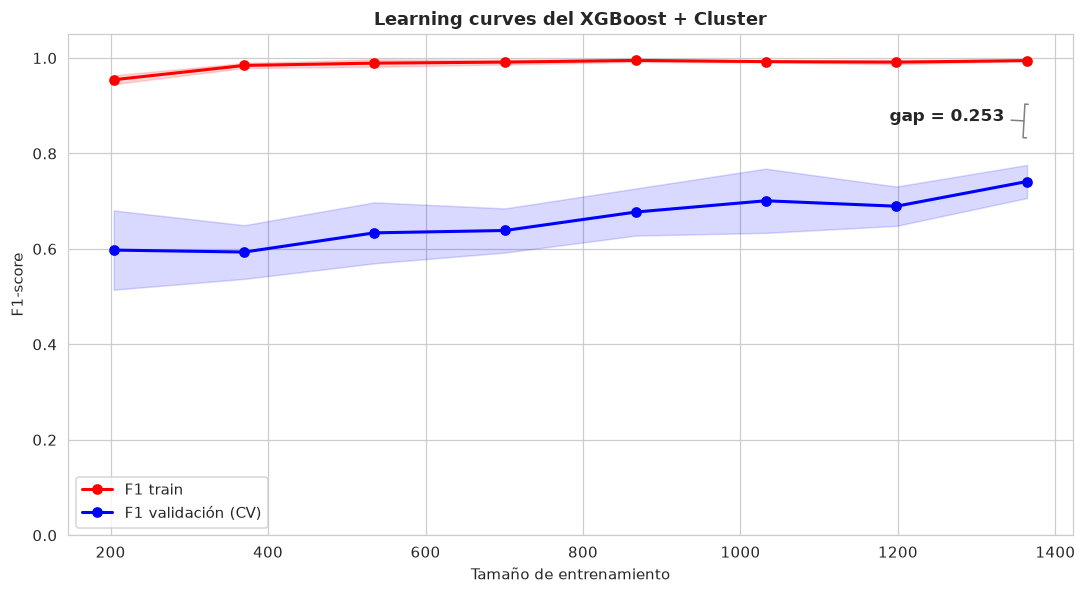

F1 train (100% datos): 0.9946 | F1 validación: 0.7413 | GAP: 0.2534
Diagnóstico: OVERFITTING marcado: gap alto → priorizar regularización en Overfitting
Tendencia: La curva de validación sigue subiendo → más datos ayudarían


In [5]:
sizes, tr_scores, va_scores = learning_curve(
    xgb_ganador(), XTR_S2, y_train, cv=CV5, scoring='f1',
    train_sizes=np.linspace(0.15, 1.0, 8), n_jobs=-1, random_state=SEED)
tr_mu, tr_sd = tr_scores.mean(1), tr_scores.std(1)
va_mu, va_sd = va_scores.mean(1), va_scores.std(1)

fig, ax = plt.subplots(figsize=(10, 5.5))
ax.plot(sizes, tr_mu, 'o-', color='red', lw=2, label='F1 train')
ax.fill_between(sizes, tr_mu - tr_sd, tr_mu + tr_sd, alpha=0.15, color='red')
ax.plot(sizes, va_mu, 'o-', color='blue', lw=2, label='F1 validación (CV)')
ax.fill_between(sizes, va_mu - va_sd, va_mu + va_sd, alpha=0.15, color='blue')
gap_final = tr_mu[-1] - va_mu[-1]
ax.annotate(f'gap = {gap_final:.3f}', xy=(sizes[-1], (tr_mu[-1] + va_mu[-1]) / 2),
            xytext=(-90, 0), textcoords='offset points', fontsize=11, fontweight='bold',
            arrowprops=dict(arrowstyle='-[', color='gray'))
ax.set_xlabel('Tamaño de entrenamiento'); ax.set_ylabel('F1-score'); ax.set_ylim(0, 1.05)
ax.set_title('Learning curves del XGBoost + Cluster', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/xgb_cluster_learning_curves.png', bbox_inches='tight'); plt.show()

print(f'F1 train (100% datos): {tr_mu[-1]:.4f} | F1 validación: {va_mu[-1]:.4f} | GAP: {gap_final:.4f}')
diag = ('OVERFITTING marcado: gap alto → priorizar regularización en Overfitting' if gap_final > 0.15 else
        'Gap moderado: algo de sobreajuste, la regularización del Overfitting puede ayudar' if gap_final > 0.08 else
        'Gap bajo: el modelo generaliza bien; el margen de mejora está en las features')
tendencia = ('La curva de validación sigue subiendo → más datos ayudarían'
             if va_mu[-1] - va_mu[-3] > 0.01 else
             'La curva de validación se aplanó → más datos aportarían poco')
print('Diagnóstico:', diag); print('Tendencia:', tendencia)

In [6]:
clf_diag = xgb_ganador().fit(XTR_S2, y_train)
f1_train_full = f1_score(y_train, clf_diag.predict(XTR_S2))
tabla_gap = pd.DataFrame({
    'Conjunto': ['Train (mismos datos de ajuste)', 'CV 5-fold (train)', 'Hold-out (20%)'],
    'F1': [round(f1_train_full, 4), round(CV_S2, 4), round(RES_S2['F1'], 4)]})
tabla_gap['Gap vs train'] = (tabla_gap['F1'] - f1_train_full).round(4)
tabla_gap.to_csv('outputs_sprint3/xgb_cluster_gap.csv', index=False)
display(tabla_gap)
print('Lectura: el F1 en train siempre es optimista; lo que importa es que CV y hold-out sean cercanos')
print(f'  |CV - holdout| = {abs(CV_S2 - RES_S2["F1"]):.4f} → '
      f'{"consistente" if abs(CV_S2 - RES_S2["F1"]) < 0.06 else "brecha a vigilar (test pequeño: 427 muestras)"}')

,Conjunto,F1,Gap vs train
0,Train (mismos datos de ajuste),0.9952,-0.0000
1,CV 5-fold (train),0.7413,-0.2539
2,Hold-out (20%),0.8036,-0.1916


Lectura: el F1 en train siempre es optimista; lo que importa es que CV y hold-out sean cercanos
  |CV - holdout| = 0.0623 → brecha a vigilar (test pequeño: 427 muestras)


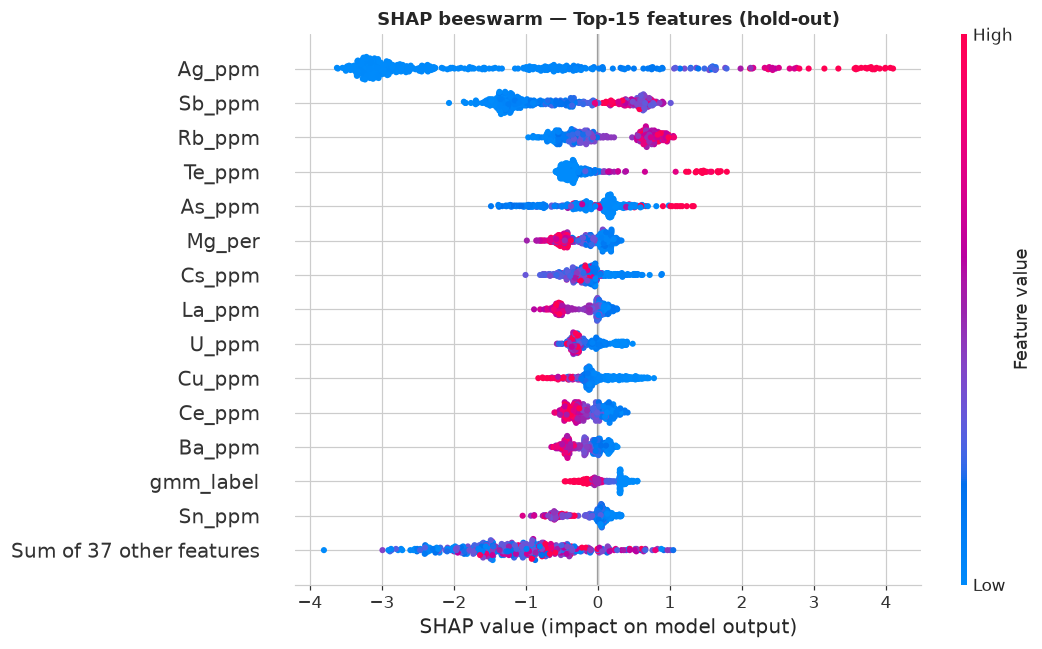

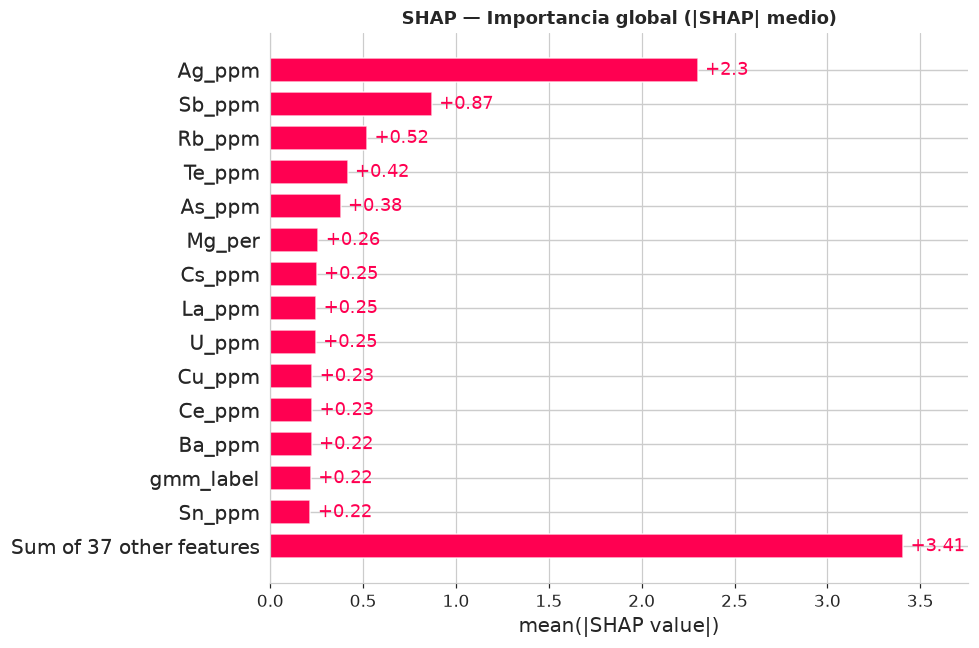

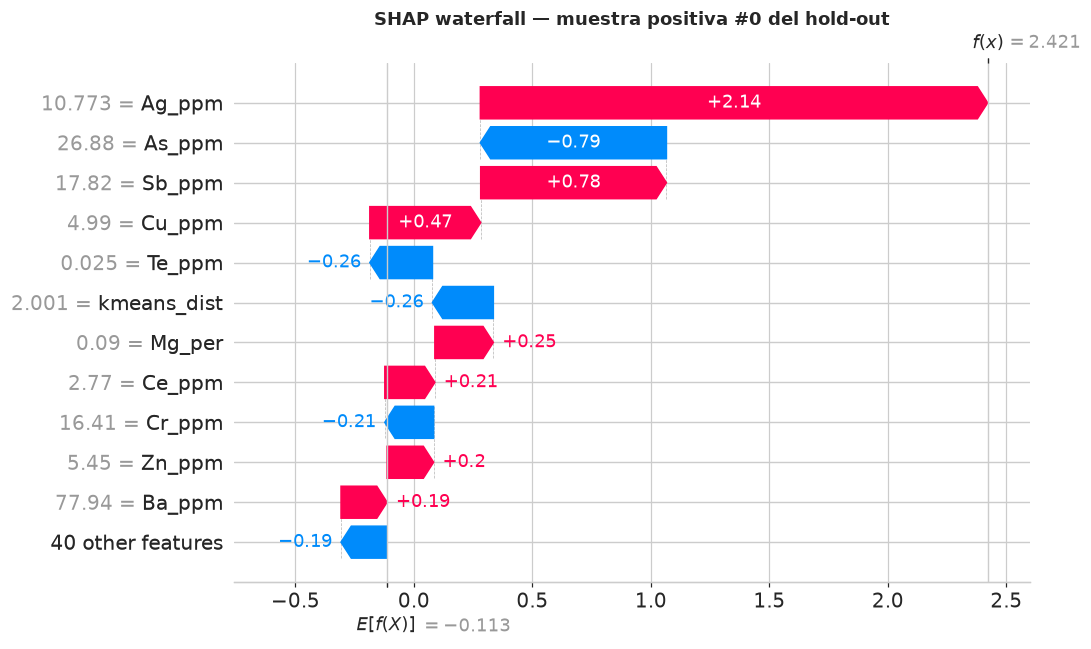

Top-10 elementos originales por SHAP (insumo para la selección top-N):


,|SHAP| medio
Ag_ppm,2.3016
Sb_ppm,0.8698
Rb_ppm,0.5213
Te_ppm,0.4165
As_ppm,0.3784
Mg_per,0.2594
Cs_ppm,0.2496
La_ppm,0.2475
U_ppm,0.2451
Cu_ppm,0.2266


Features de clustering en el top-15 SHAP: 1 de 5


In [7]:
explainer = shap.TreeExplainer(clf_diag)
sv = explainer(XTE_S2)

# beeswarm: direccion e intensidad del efecto de cada feature
shap.plots.beeswarm(sv, max_display=15, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title('SHAP beeswarm — Top-15 features (hold-out)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/xgb_cluster_shap_beeswarm.png', bbox_inches='tight'); plt.show()

# barras: importancia global |SHAP| medio
shap.plots.bar(sv, max_display=15, show=False)
plt.gcf().set_size_inches(9, 6)
plt.title('SHAP — Importancia global (|SHAP| medio)', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/xgb_cluster_shap_bar.png', bbox_inches='tight'); plt.show()

# waterfall: anatomia de una prediccion positiva correcta
idx_pos = np.where((y_test.values == 1) & (RES_S2['_pred'] == 1))[0][0]
shap.plots.waterfall(sv[idx_pos], max_display=12, show=False)
plt.gcf().set_size_inches(10, 6)
plt.title(f'SHAP waterfall — muestra positiva #{idx_pos} del hold-out', fontweight='bold')
plt.tight_layout(); plt.savefig('outputs_sprint3/xgb_cluster_shap_waterfall.png', bbox_inches='tight'); plt.show()

# ranking de elementos ORIGINALES (sin features de cluster) -> insumo del S2
imp_shap = pd.Series(np.abs(sv.values).mean(0), index=XTE_S2.columns).sort_values(ascending=False)
RANKING_ELEMENTOS = [f for f in imp_shap.index if f in FEATURES_BASE]
imp_shap.to_csv('outputs_sprint3/xgb_cluster_shap_importancias.csv', header=['shap_medio'])
print('Top-10 elementos originales por SHAP (insumo para la selección top-N):')
display(imp_shap[imp_shap.index.isin(FEATURES_BASE)].head(10).round(4).to_frame('|SHAP| medio'))
n_clu_top15 = sum(1 for f in imp_shap.head(15).index if f not in FEATURES_BASE)
print(f'Features de clustering en el top-15 SHAP: {n_clu_top15} de 5')

## Selección de features top-N (solo elementos sin Au)

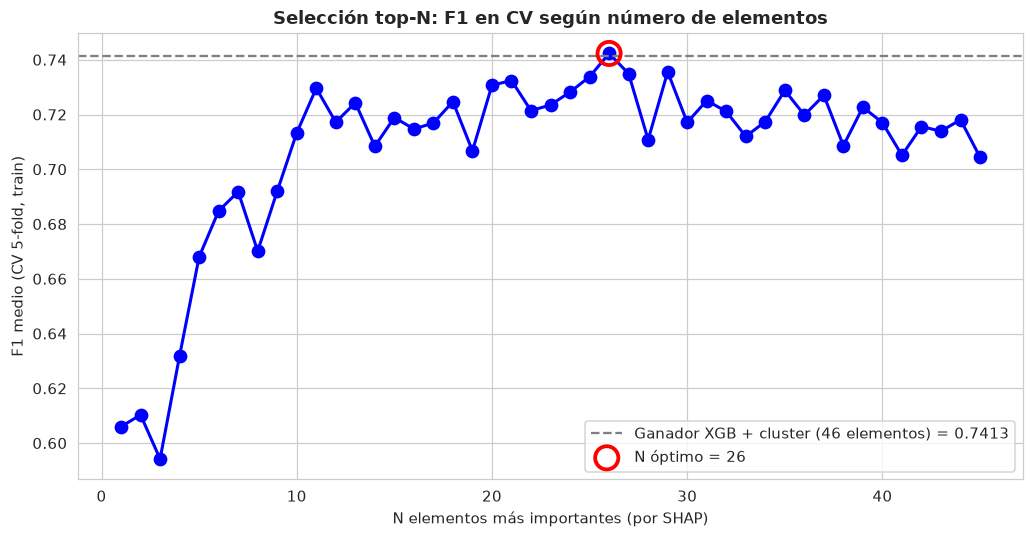

  [Top-N] Top-26 elementos + cluster: F1 CV=0.7423 | F1 hold-out=0.7664
Elementos seleccionados (top-26): ['Ag_ppm', 'Sb_ppm', 'Rb_ppm', 'Te_ppm', 'As_ppm', 'Mg_per', 'Cs_ppm', 'La_ppm', 'U_ppm', 'Cu_ppm', 'Ce_ppm', 'Ba_ppm', 'Sn_ppm', 'Cr_ppm', 'P_ppm', 'Al_per', 'Fe_per', 'Ta_ppm', 'Be_ppm', 'Zr_ppm', 'Mo_ppm', 'Ni_ppm', 'Sr_ppm', 'Bi_ppm', 'Na_per', 'Ge_ppm']


In [8]:
NS = np.arange(1, 46)
res_topn = []
for n in NS:
    top_els = RANKING_ELEMENTOS[:n]
    Xtr_n = pd.concat([X_train[top_els], CLU_TRAIN], axis=1)
    cvf1 = f1_cv(xgb_ganador(), Xtr_n)
    res_topn.append({'N': n, 'F1 CV': cvf1})
tabla_topn = pd.DataFrame(res_topn)
tabla_topn['F1 CV'] = tabla_topn['F1 CV'].round(4)
N_OPT = int(tabla_topn.loc[tabla_topn['F1 CV'].idxmax(), 'N'])
tabla_topn.to_csv('outputs_sprint3/xgb_cluster_f1_vs_n.csv', index=False)

fig, ax = plt.subplots(figsize=(9.5, 5))
ax.plot(tabla_topn['N'], tabla_topn['F1 CV'], 'o-', color='blue', lw=2, markersize=8)
ax.axhline(CV_S2, ls='--', color='gray', label=f'Ganador XGB + cluster (46 elementos) = {CV_S2:.4f}')
ax.scatter([N_OPT], [tabla_topn['F1 CV'].max()], s=230, facecolors='none',
           edgecolors='red', linewidths=2.5, zorder=5, label=f'N óptimo = {N_OPT}')
ax.set_xlabel('N elementos más importantes (por SHAP)'); ax.set_ylabel('F1 medio (CV 5-fold, train)')
ax.set_title('Selección top-N: F1 en CV según número de elementos', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/xgb_cluster_topn_seleccion.png', bbox_inches='tight'); plt.show()

TOP_ELS = RANKING_ELEMENTOS[:N_OPT]
XTR_TOPN = pd.concat([X_train[TOP_ELS], CLU_TRAIN], axis=1)
XTE_TOPN = pd.concat([X_test[TOP_ELS], CLU_TEST], axis=1)
CV_TOPN, RES_TOPN = log_run('Top-N', f'Top-{N_OPT} elementos + cluster',
                            xgb_ganador, XTR_TOPN, XTE_TOPN, {'N': N_OPT})
print(f'Elementos seleccionados (top-{N_OPT}):', TOP_ELS)

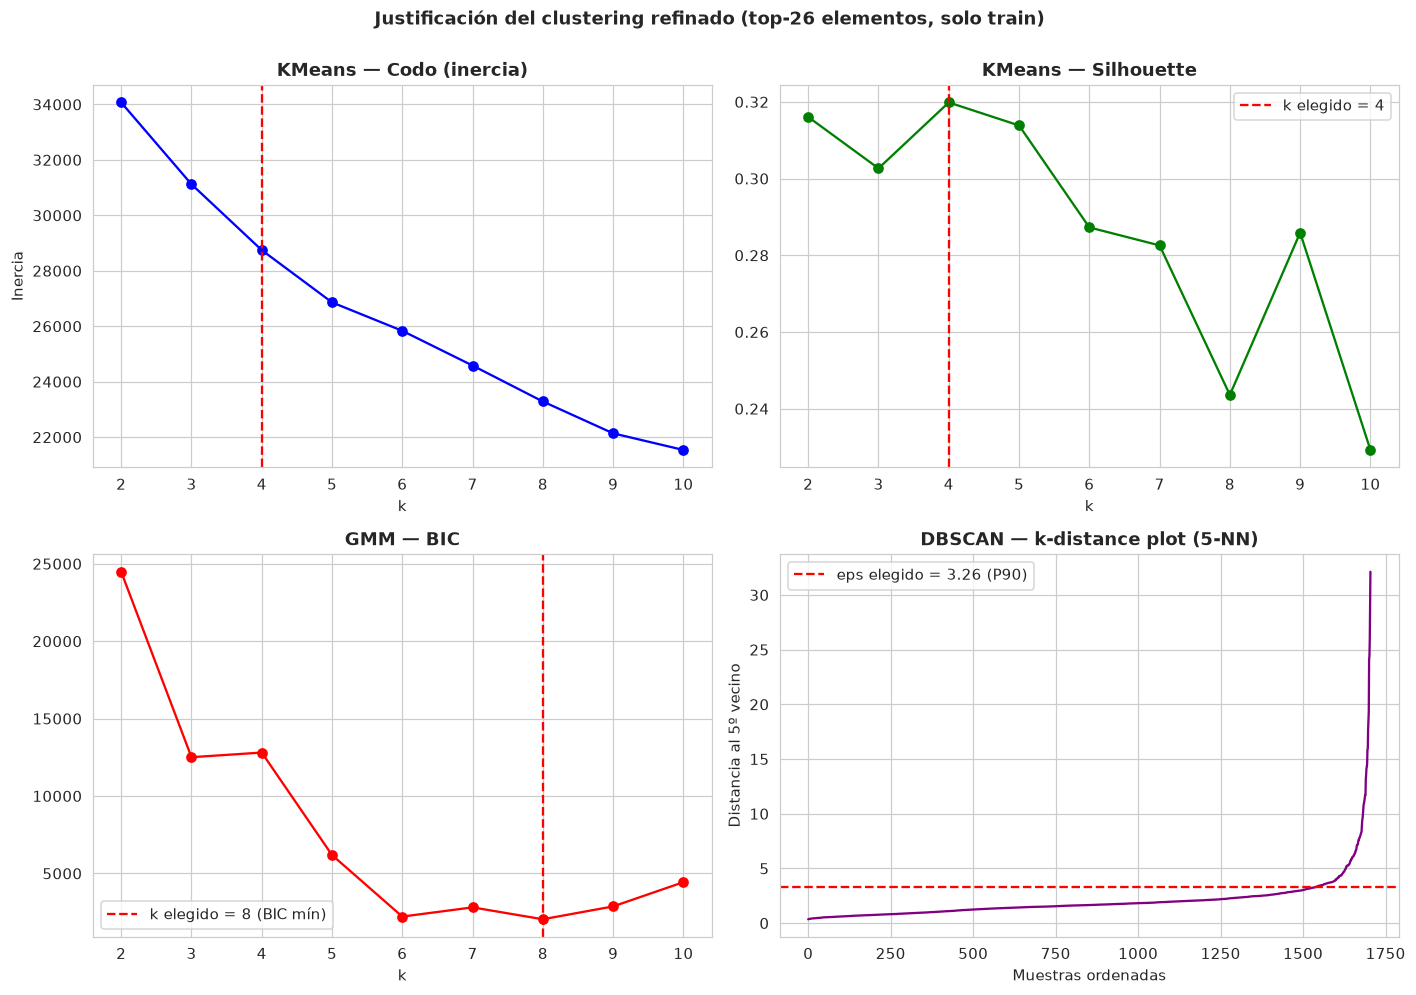

Clustering refinado: KMeans k=4 | GMM k=8 | DBSCAN eps=3.26


In [9]:
SC_REF = StandardScaler().fit(X_train[TOP_ELS])
Xtr_ref_sc, Xte_ref_sc = SC_REF.transform(X_train[TOP_ELS]), SC_REF.transform(X_test[TOP_ELS])

K_KM_R, K_GM_R, EPS_R, inercias_r, silus_r, bics_r, d5_r = elegir_k_clustering(Xtr_ref_sc)
ks = list(range(2, 11))

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes[0,0].plot(ks, inercias_r, marker='o', color='blue')
axes[0,0].axvline(K_KM_R, ls='--', color='red'); axes[0,0].set_title('KMeans — Codo (inercia)', fontweight='bold')
axes[0,0].set_xlabel('k'); axes[0,0].set_ylabel('Inercia')
axes[0,1].plot(ks, silus_r, marker='o', color='green')
axes[0,1].axvline(K_KM_R, ls='--', color='red', label=f'k elegido = {K_KM_R}')
axes[0,1].set_title('KMeans — Silhouette', fontweight='bold'); axes[0,1].set_xlabel('k'); axes[0,1].legend()
axes[1,0].plot(ks, bics_r, marker='o', color='red')
axes[1,0].axvline(K_GM_R, ls='--', color='red', label=f'k elegido = {K_GM_R} (BIC mín)')
axes[1,0].set_title('GMM — BIC', fontweight='bold'); axes[1,0].set_xlabel('k'); axes[1,0].legend()
axes[1,1].plot(d5_r, color='purple')
axes[1,1].axhline(EPS_R, ls='--', color='red', label=f'eps elegido = {EPS_R:.2f} (P90)')
axes[1,1].set_title('DBSCAN — k-distance plot (5-NN)', fontweight='bold')
axes[1,1].set_xlabel('Muestras ordenadas'); axes[1,1].set_ylabel('Distancia al 5º vecino'); axes[1,1].legend()
plt.suptitle(f'Justificación del clustering refinado (top-{N_OPT} elementos, solo train)',
             fontweight='bold', y=1.0)
plt.tight_layout(); plt.savefig('outputs_sprint3/ref_xgb_cluster_justificacion.png', bbox_inches='tight'); plt.show()
print(f'Clustering refinado: KMeans k={K_KM_R} | GMM k={K_GM_R} | DBSCAN eps={EPS_R:.2f}')

In [10]:
KM_R, GM_R, NN_R = ajustar_clustering(Xtr_ref_sc, K_KM_R, K_GM_R, EPS_R)
CLU_REF_TRAIN = features_clustering(Xtr_ref_sc, KM_R, GM_R, NN_R, EPS_R, 'ref_').set_index(X_train.index)
CLU_REF_TEST = features_clustering(Xte_ref_sc, KM_R, GM_R, NN_R, EPS_R, 'ref_').set_index(X_test.index)

# composicion del target por cluster refinado (train)
comp = []
for col in ['ref_kmeans_label', 'ref_gmm_label', 'ref_dbscan_outlier']:
    t = pd.crosstab(CLU_REF_TRAIN[col], y_train, normalize='index')
    t.columns = ['% Neg', '% Pos']
    t.insert(0, 'n', pd.crosstab(CLU_REF_TRAIN[col], y_train).sum(axis=1))
    t.index = [f'{col}={i}' for i in t.index]
    comp.append(t)
tabla_comp_ref = pd.concat(comp).round(3)
tabla_comp_ref.to_csv('outputs_sprint3/ref_xgb_cluster_composicion.csv')
print(f'Composición del target por cluster refinado (train) — tasa base: {y_train.mean():.3f}')
display(tabla_comp_ref)

# candidato: top-N elementos + clustering REFINADO (reemplaza al generico del Sprint 2)
XTR_REF = pd.concat([X_train[TOP_ELS], CLU_REF_TRAIN], axis=1)
XTE_REF = pd.concat([X_test[TOP_ELS], CLU_REF_TEST], axis=1)
CV_REF, RES_REF = log_run('XGB + Cluster + refinado', f'Top-{N_OPT} + cluster + refinado',
                          xgb_ganador, XTR_REF, XTE_REF, {'N': N_OPT, 'k_kmeans': K_KM_R})

# decision del mejor set de features (por F1 CV en train)
candidatos_sets = {
    'Ganador XGB (46 els + cluster)': (CV_S2, XTR_S2, XTE_S2),
    f'Top-{N_OPT} + cluster XGB': (CV_TOPN, XTR_TOPN, XTE_TOPN),
    f'Top-{N_OPT} + cluster XGB + refinado': (CV_REF, XTR_REF, XTE_REF)}
MEJOR_SET_NOMBRE = max(candidatos_sets, key=lambda k: candidatos_sets[k][0])
_, XTR_BEST, XTE_BEST = candidatos_sets[MEJOR_SET_NOMBRE]
print('\nComparación de sets (F1 CV train):')
for nom, (cvf, _, _) in candidatos_sets.items():
    marca = ' ← MEJOR SET' if nom == MEJOR_SET_NOMBRE else ''
    print(f'  {nom}: {cvf:.4f}{marca}')

Composición del target por cluster refinado (train) — tasa base: 0.122


,n,% Neg,% Pos
ref_kmeans_label=0,314,0.981,0.019
ref_kmeans_label=1,826,0.798,0.202
ref_kmeans_label=2,528,0.983,0.017
ref_kmeans_label=3,37,0.297,0.703
ref_gmm_label=0,363,0.738,0.262
ref_gmm_label=1,517,0.988,0.012
ref_gmm_label=2,2,0.000,1.000
ref_gmm_label=3,148,0.581,0.419
ref_gmm_label=4,331,0.982,0.018
ref_gmm_label=5,314,0.930,0.070


  [XGB + Cluster + refinado] Top-26 + cluster + refinado: F1 CV=0.7238 | F1 hold-out=0.7736

Comparación de sets (F1 CV train):
  Ganador XGB (46 els + cluster): 0.7413
  Top-26 + cluster XGB: 0.7423 ← MEJOR SET
  Top-26 + cluster XGB + refinado: 0.7238


## Control de overfitting

In [11]:
RCV = RepeatedStratifiedKFold(n_splits=5, n_repeats=3, random_state=SEED)

def objective_xgb_rcv(trial):
    p = {'n_estimators': trial.suggest_int('n_estimators', 100, 700),
         'max_depth': trial.suggest_int('max_depth', 3, 20),
         'learning_rate': trial.suggest_float('learning_rate', 1e-3, 0.3, log=True),
         'subsample': trial.suggest_float('subsample', 0.6, 1.0),
         'colsample_bytree': trial.suggest_float('colsample_bytree', 0.6, 1.0),
         'min_child_weight': trial.suggest_float('min_child_weight', 1, 20),
         'gamma': trial.suggest_float('gamma', 0, 5),
         'reg_alpha': trial.suggest_float('reg_alpha', 1e-4, 10, log=True),
         'reg_lambda': trial.suggest_float('reg_lambda', 1e-4, 10, log=True),
         'scale_pos_weight': trial.suggest_float('scale_pos_weight', 1.0, 10.0)}
    clf = xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', tree_method='hist',
                            n_jobs=-1, **p)
    return float(np.mean(cross_val_score(clf, XTR_BEST, y_train, scoring='f1', cv=RCV, n_jobs=-1)))

t0 = time.time()
study_xgb = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_xgb.optimize(objective_xgb_rcv, n_trials=50, show_progress_bar=False)
print(f'Optuna CV repetida (5×3, 50 trials, {time.time()-t0:.0f}s) sobre "{MEJOR_SET_NOMBRE}"')
print(f'Mejor F1 CV-repetida: {study_xgb.best_value:.4f}')
print('Mejores params:', study_xgb.best_params)
with open('outputs_sprint3/optuna_rcv_best_params.json', 'w') as f:
    json.dump(study_xgb.best_params, f, indent=2)

Optuna CV repetida (5×3, 50 trials, 206s) sobre "Top-26 + cluster XGB"
Mejor F1 CV-repetida: 0.7402
Mejores params: {'n_estimators': 663, 'max_depth': 16, 'learning_rate': 0.03537436154281675, 'subsample': 0.9233818868173533, 'colsample_bytree': 0.7903291491672468, 'min_child_weight': 5.386640431657699, 'gamma': 0.009163281072882112, 'reg_alpha': 0.0014494939051976278, 'reg_lambda': 0.0039495541246107515, 'scale_pos_weight': 2.11193819570758}


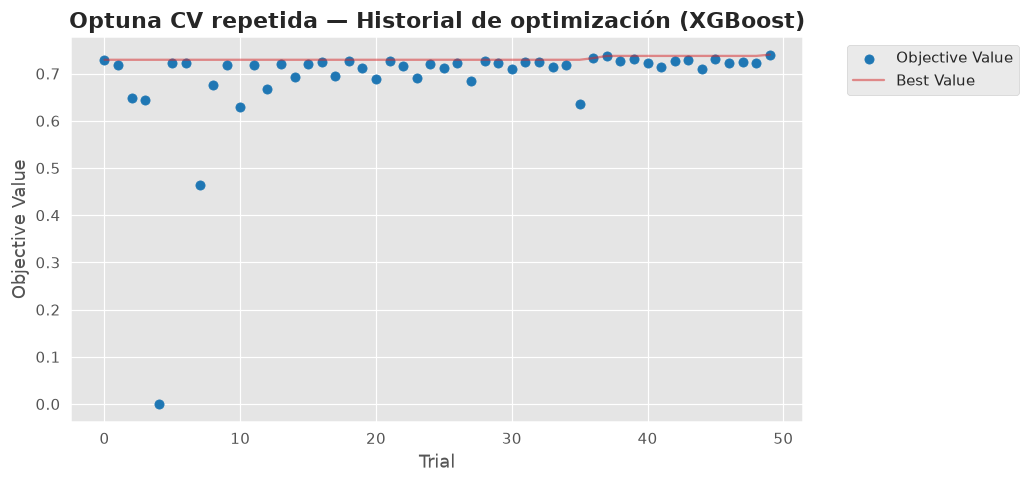

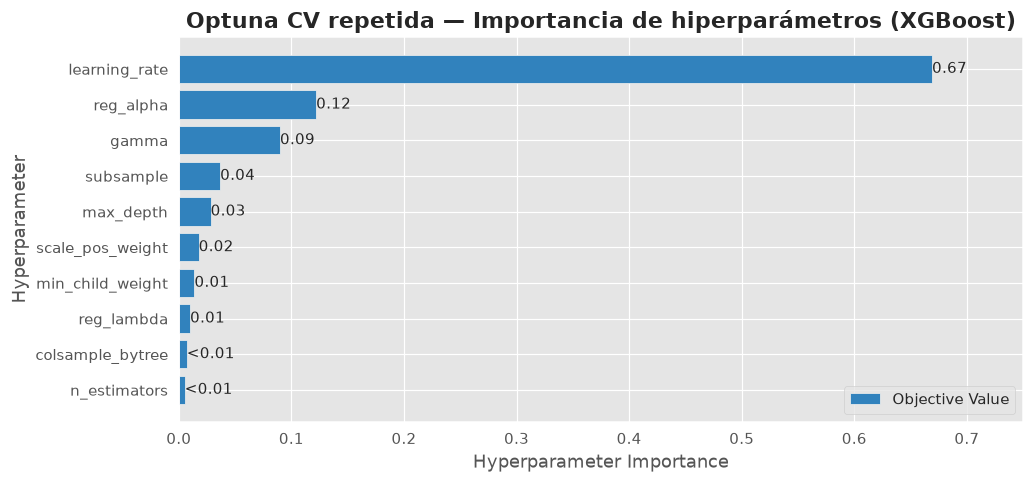

In [12]:
from optuna.visualization.matplotlib import plot_optimization_history, plot_param_importances

ax = plot_optimization_history(study_xgb)
ax.set_title('')
ax.set_title('Optuna CV repetida — Historial de optimización (XGBoost)', fontweight='bold')
plt.gcf().set_size_inches(9.5, 4.5); plt.tight_layout()
plt.savefig('outputs_sprint3/optuna_rcv_historial.png', bbox_inches='tight'); plt.show()

ax = plot_param_importances(study_xgb)
ax.set_title('', loc='left')   # Optuna pone su titulo con loc='left'
ax.set_title('Optuna CV repetida — Importancia de hiperparámetros (XGBoost)', fontweight='bold')
plt.gcf().set_size_inches(9.5, 4.5); plt.tight_layout()
plt.savefig('outputs_sprint3/optuna_rcv_importancia.png', bbox_inches='tight'); plt.show()

In [13]:
def xgb_rcv():
    return xgb.XGBClassifier(random_state=SEED, eval_metric='logloss', tree_method='hist',
                             n_jobs=-1, **study_xgb.best_params)
CV_RCV, RES_RCV = log_run('Overfitting', 'XGB Optuna CV-repetida (mejor set)',
                          xgb_rcv, XTR_BEST, XTE_BEST, study_xgb.best_params)

# mejor XGBoost del proyecto hasta este punto (decision por F1 CV en train)
candidatos_xgb = {
    'Ganador XGB + cluster': (CV_S2, xgb_ganador, XTR_S2, XTE_S2, RES_S2),
    f'Mejor set  + params XGB + cluster': (candidatos_sets[MEJOR_SET_NOMBRE][0], xgb_ganador,
                                        XTR_BEST, XTE_BEST, None),
    'Mejor set + Optuna CV-repetida': (CV_RCV, xgb_rcv, XTR_BEST, XTE_BEST, RES_RCV)}
MEJOR_XGB_NOMBRE = max(candidatos_xgb, key=lambda k: candidatos_xgb[k][0])
CV_XGB_BEST, FACTORY_XGB_BEST, XTR_FINAL, XTE_FINAL, _tmp = candidatos_xgb[MEJOR_XGB_NOMBRE]
RES_XGB_BEST = _tmp if _tmp is not None else evaluar_holdout(FACTORY_XGB_BEST(), XTR_FINAL, XTE_FINAL)
print('\nMejor XGBoost del proyecto (por F1 CV):', MEJOR_XGB_NOMBRE)
print(f'  F1 CV = {CV_XGB_BEST:.4f} | F1 hold-out = {RES_XGB_BEST["F1"]:.4f} | '
      f'features = {XTR_FINAL.shape[1]}')

  [Overfitting] XGB Optuna CV-repetida (mejor set): F1 CV=0.7336 | F1 hold-out=0.7451

Mejor XGBoost del proyecto (por F1 CV): Mejor set  + params XGB + cluster
  F1 CV = 0.7423 | F1 hold-out = 0.7664 | features = 31


## Comparar con el modelo MLP

In [14]:
def mlp_pipeline(params):
    return ImbPipeline([('scaler', StandardScaler()),
                        ('smote', SMOTE(random_state=SEED, k_neighbors=5)),
                        ('mlp', MLPClassifier(random_state=SEED, max_iter=300,
                                              early_stopping=True, n_iter_no_change=15, **params))])

def objective_mlp(trial):
    n_capas = trial.suggest_int('n_capas', 1, 3)
    unidades = trial.suggest_categorical('unidades', [16, 32, 64, 128])
    p = {'hidden_layer_sizes': tuple([unidades] * n_capas),
         'alpha': trial.suggest_float('alpha', 1e-5, 1e-1, log=True),
         'learning_rate_init': trial.suggest_float('learning_rate_init', 1e-4, 1e-2, log=True),
         'activation': trial.suggest_categorical('activation', ['relu', 'tanh']),
         'batch_size': trial.suggest_categorical('batch_size', [32, 64, 128, 256])}
    return float(np.mean(cross_val_score(mlp_pipeline(p), XTR_FINAL, y_train,
                                         scoring='f1', cv=CV5, n_jobs=-1)))

t0 = time.time()
study_mlp = optuna.create_study(direction='maximize', sampler=TPESampler(seed=SEED))
study_mlp.optimize(objective_mlp, n_trials=50, show_progress_bar=False)
bp = study_mlp.best_params
MLP_PARAMS = {'hidden_layer_sizes': tuple([bp['unidades']] * bp['n_capas']),
              'alpha': bp['alpha'], 'learning_rate_init': bp['learning_rate_init'],
              'activation': bp['activation'], 'batch_size': bp['batch_size']}
print(f'Optuna MLP (50 trials, {time.time()-t0:.0f}s) → mejor F1 CV = {study_mlp.best_value:.4f}')
print('Arquitectura elegida:', MLP_PARAMS)
with open('outputs_sprint3/mlp_best_params.json', 'w') as f:
    json.dump({k: str(v) for k, v in MLP_PARAMS.items()}, f, indent=2)

Optuna MLP (50 trials, 250s) → mejor F1 CV = 0.6612
Arquitectura elegida: {'hidden_layer_sizes': (64, 64, 64), 'alpha': 1.3731894683166336e-05, 'learning_rate_init': 0.008095374290609527, 'activation': 'relu', 'batch_size': 64}


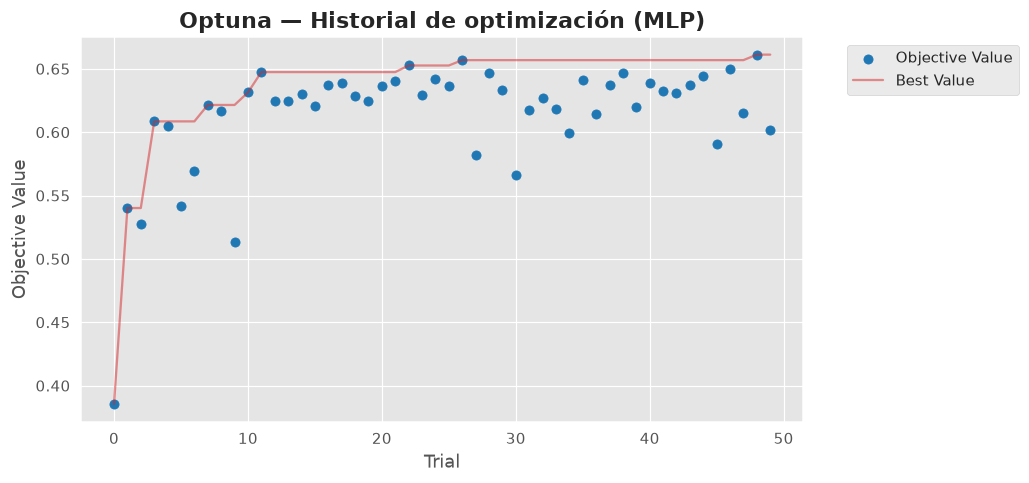

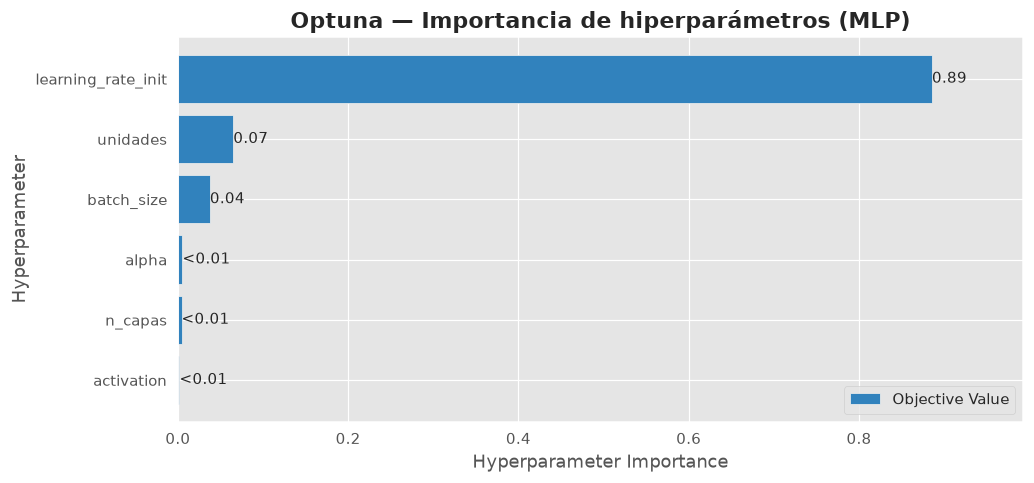

In [15]:
ax = plot_optimization_history(study_mlp)
ax.set_title('')
ax.set_title('Optuna — Historial de optimización (MLP)', fontweight='bold')
plt.gcf().set_size_inches(9.5, 4.5); plt.tight_layout()
plt.savefig('outputs_sprint3/mlp_optuna_historial.png', bbox_inches='tight'); plt.show()

ax = plot_param_importances(study_mlp)
ax.set_title('', loc='left')   # Optuna pone su titulo con loc='left'
ax.set_title('Optuna — Importancia de hiperparámetros (MLP)', fontweight='bold')
plt.gcf().set_size_inches(9.5, 4.5); plt.tight_layout()
plt.savefig('outputs_sprint3/mlp_optuna_importancia.png', bbox_inches='tight'); plt.show()

In [16]:
CV_MLP, RES_MLP = log_run('MLP', 'Optuna (mismas features que mejor XGB)',
                          lambda: mlp_pipeline(MLP_PARAMS), XTR_FINAL, XTE_FINAL,
                          {k: str(v) for k, v in MLP_PARAMS.items()})
print(f'\nMLP={RES_MLP["F1"]:.4f} vs XGB={RES_XGB_BEST["F1"]:.4f} (hold-out) - '
      f'{"SÍ" if RES_MLP["F1"] > RES_XGB_BEST["F1"] else "NO"}')

  [MLP] Optuna (mismas features que mejor XGB): F1 CV=0.6612 | F1 hold-out=0.6549

MLP=0.6549 vs XGB=0.7664 (hold-out) - NO


## Comparativa Final

In [17]:
# tablero con todas las configuraciones registradas en MLflow durante el sprint
tabla_runs = pd.DataFrame(REGISTRO)
tabla_runs = tabla_runs.sort_values('F1 (hold-out)', ascending=False).reset_index(drop=True)
tabla_runs.to_csv('outputs_sprint3/tablero_runs.csv', index=False)
print(f'Runs registrados en MLflow: {len(tabla_runs)} (experimento Sprint3)')
display(tabla_runs)

# ganador definitivo: por F1 en hold-out (mismo criterio que el veredicto del Sprint 2)
if RES_MLP['F1'] > RES_XGB_BEST['F1']:
    GANADOR_NOMBRE, RES_GANADOR = 'MLP', RES_MLP
    FACTORY_GANADOR = lambda: mlp_pipeline(MLP_PARAMS)
else:
    GANADOR_NOMBRE, RES_GANADOR = f'XGBoost ({MEJOR_XGB_NOMBRE})', RES_XGB_BEST
    FACTORY_GANADOR = FACTORY_XGB_BEST
print(f'\nGANADOR DEFINITIVO del Sprint 3: {GANADOR_NOMBRE} : F1 hold-out = {RES_GANADOR["F1"]:.4f}')

Runs registrados en MLflow: 5 (experimento Sprint3)


,Etapa,Config,n_features,F1 CV (train),F1 (hold-out),Accuracy (hold-out),Precision (hold-out),Recall (hold-out),AUC-ROC (hold-out)
0,S0 Referencia,Ganador Sprint 2 (XGB + Cluster),51,0.7413,0.8036,0.9485,0.7500,0.8654,0.9596
1,XGB + Cluster + refinado,Top-26 + cluster + refinado,31,0.7238,0.7736,0.9438,0.7593,0.7885,0.9673
2,Top-N,Top-26 elementos + cluster,31,0.7423,0.7664,0.9415,0.7455,0.7885,0.9613
3,Overfitting,XGB Optuna CV-repetida (mejor set),31,0.7336,0.7451,0.9391,0.7600,0.7308,0.9642
4,MLP,Optuna (mismas features que mejor XGB),31,0.6612,0.6549,0.9087,0.6066,0.7115,0.9206



GANADOR DEFINITIVO del Sprint 3: XGBoost (Mejor set  + params XGB + cluster) : F1 hold-out = 0.7664


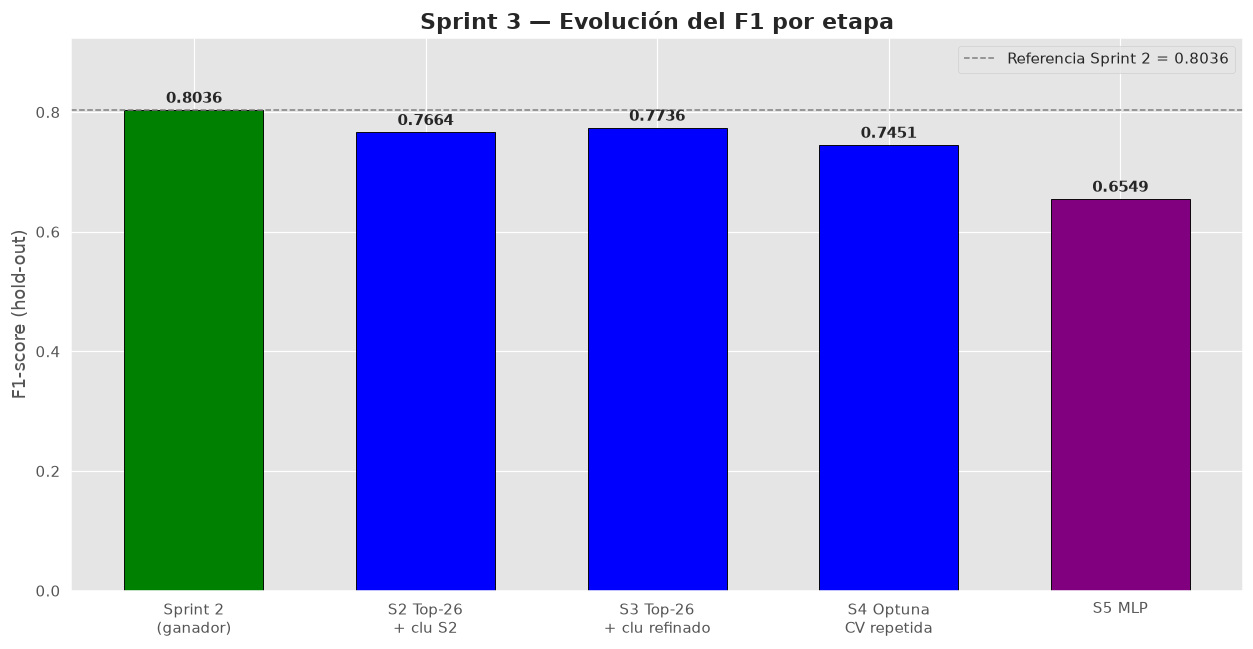

In [18]:
etapas_plot = [('Sprint 2\n(ganador)', RES_S2['F1']),
               (f'S2 Top-{N_OPT}\n+ clu S2', RES_TOPN['F1']),
               (f'S3 Top-{N_OPT}\n+ clu refinado', RES_REF['F1']),
               ('S4 Optuna\nCV repetida', RES_RCV['F1']),
               ('S5 MLP', RES_MLP['F1'])]
nombres = [e[0] for e in etapas_plot]; valores = [e[1] for e in etapas_plot]
colores = ['gray', 'blue', 'blue', 'blue', 'purple']

fig, ax = plt.subplots(figsize=(11.5, 6))
bars = ax.bar(nombres, valores, color=colores, width=0.6, edgecolor='black', lw=0.6)
i_max = int(np.argmax(valores))
bars[i_max].set_color('green'); bars[i_max].set_edgecolor('black')
for b, v in zip(bars, valores):
    ax.text(b.get_x() + b.get_width()/2, v + 0.012, f'{v:.4f}', ha='center', fontweight='bold')
ax.axhline(RES_S2['F1'], ls='--', color='gray', lw=1,
           label=f'Referencia Sprint 2 = {RES_S2["F1"]:.4f}')
ax.set_ylabel('F1-score (hold-out)'); ax.set_ylim(0, max(valores) + 0.12)
ax.set_title('Sprint 3 — Evolución del F1 por etapa', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/evolucion_f1.png', bbox_inches='tight'); plt.show()

## Calibración y ajuste de umbral

Brier score OOF (train) — menor es mejor:
  Sin calibrar: 0.0500
  Sigmoid (Platt): 0.0488
  Isotónica: 0.0482 - ELEGIDA


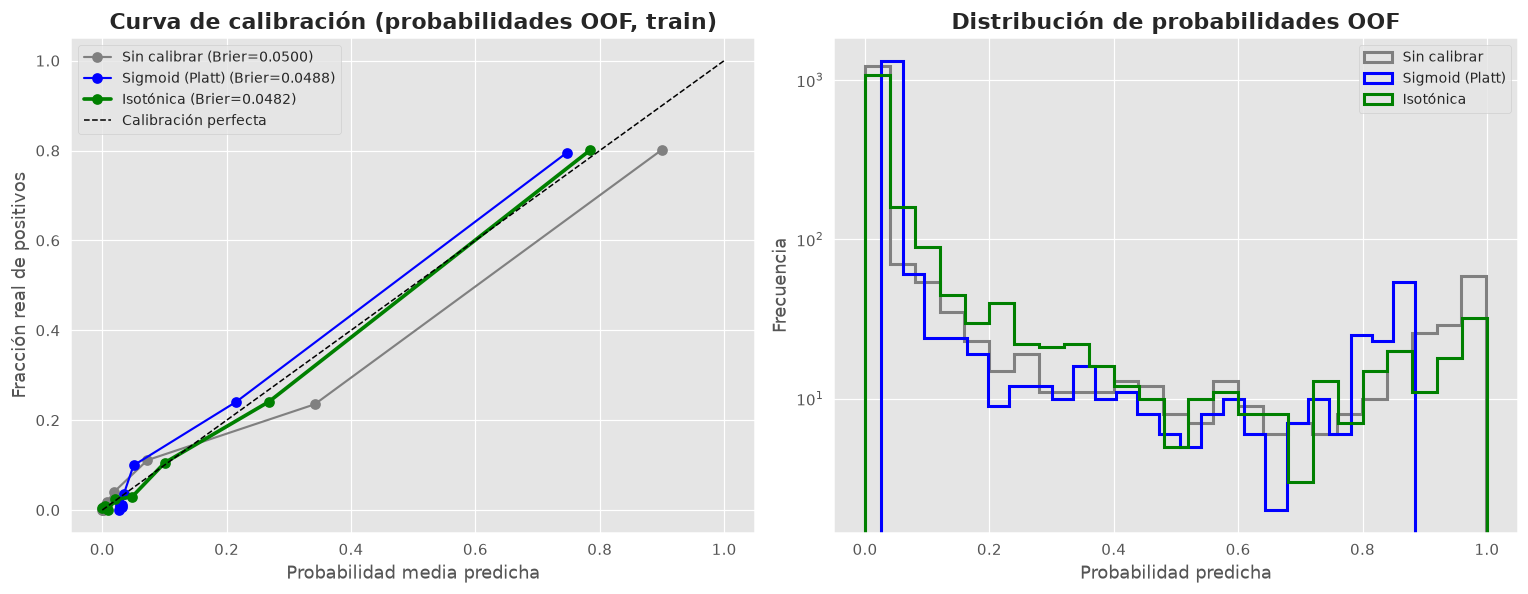

In [19]:
# ---- Calibracion: sin calibrar vs sigmoid vs isotonica (elegida por Brier OOF en train) ----
variantes_cal = {
    'Sin calibrar': FACTORY_GANADOR(),
    'Sigmoid (Platt)': CalibratedClassifierCV(FACTORY_GANADOR(), method='sigmoid', cv=CV5),
    'Isotónica': CalibratedClassifierCV(FACTORY_GANADOR(), method='isotonic', cv=CV5)}

briers_oof, prob_oof_cal = {}, {}
for nom, clf in variantes_cal.items():
    p_oof = cross_val_predict(clf, XTR_FINAL, y_train, cv=CV5, method='predict_proba', n_jobs=-1)[:, 1]
    briers_oof[nom] = brier_score_loss(y_train, p_oof)
    prob_oof_cal[nom] = p_oof
MEJOR_CAL = min(briers_oof, key=briers_oof.get)
print('Brier score OOF (train) — menor es mejor:')
for nom, b in briers_oof.items():
    print(f'  {nom}: {b:.4f}' + (' - ELEGIDA' if nom == MEJOR_CAL else ''))

# curva de calibracion (con probabilidades OOF de train: sin usar el hold-out)
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
cal_colors = {'Sin calibrar': 'gray', 'Sigmoid (Platt)': 'blue', 'Isotónica': 'green'}
for nom, p_oof in prob_oof_cal.items():
    frac_pos, media_pred = calibration_curve(y_train, p_oof, n_bins=10, strategy='quantile')
    axes[0].plot(media_pred, frac_pos, 'o-', color=cal_colors[nom],
                 lw=2.4 if nom == MEJOR_CAL else 1.4,
                 label=f'{nom} (Brier={briers_oof[nom]:.4f})')
    axes[1].hist(p_oof, bins=25, histtype='step', lw=2, color=cal_colors[nom], label=nom)
axes[0].plot([0, 1], [0, 1], '--', color='black', lw=1, label='Calibración perfecta')
axes[0].set_xlabel('Probabilidad media predicha'); axes[0].set_ylabel('Fracción real de positivos')
axes[0].set_title('Curva de calibración (probabilidades OOF, train)', fontweight='bold')
axes[0].legend(fontsize=9)
axes[1].set_xlabel('Probabilidad predicha'); axes[1].set_ylabel('Frecuencia'); axes[1].set_yscale('log')
axes[1].set_title('Distribución de probabilidades OOF', fontweight='bold'); axes[1].legend(fontsize=9)
plt.tight_layout(); plt.savefig('outputs_sprint3/calibracion.png', bbox_inches='tight'); plt.show()

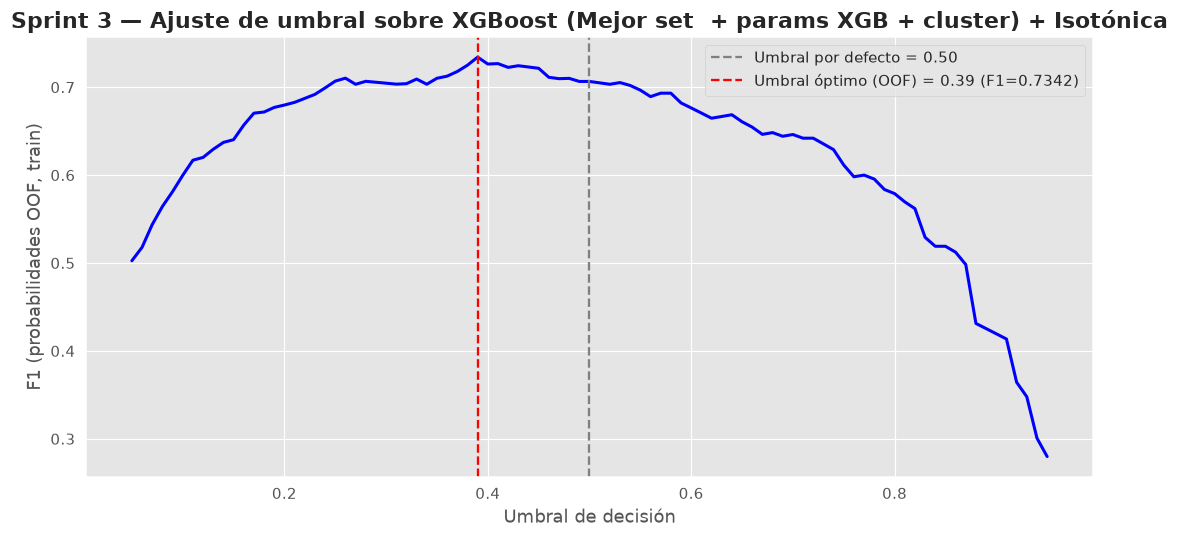

MODELO FINAL: XGBoost (Mejor set  + params XGB + cluster) + Isotónica + umbral 0.39
  F1: 0.7429
  Accuracy: 0.9368
  Precision: 0.7358
  Recall: 0.7500
  AUC-ROC: 0.9625


In [20]:
# ---- Ajuste de umbral con las probabilidades OOF de la variante elegida ----
p_oof = prob_oof_cal[MEJOR_CAL]
umbrales = np.arange(0.05, 0.96, 0.01)
f1s_u = [f1_score(y_train, (p_oof >= u).astype(int)) for u in umbrales]
UMBRAL_OPT = float(umbrales[int(np.argmax(f1s_u))])

fig, ax = plt.subplots(figsize=(10, 5))
ax.plot(umbrales, f1s_u, color='blue', lw=2)
ax.axvline(0.5, ls='--', color='gray', label='Umbral por defecto = 0.50')
ax.axvline(UMBRAL_OPT, ls='--', color='red',
           label=f'Umbral óptimo (OOF) = {UMBRAL_OPT:.2f} (F1={max(f1s_u):.4f})')
ax.set_xlabel('Umbral de decisión'); ax.set_ylabel('F1 (probabilidades OOF, train)')
ax.set_title(f'Sprint 3 — Ajuste de umbral sobre {GANADOR_NOMBRE} + {MEJOR_CAL}', fontweight='bold')
ax.legend()
plt.tight_layout(); plt.savefig('outputs_sprint3/ajuste_umbral.png', bbox_inches='tight'); plt.show()

# ---- Aplicacion al hold-out (UNA sola vez) ----
clf_final = variantes_cal[MEJOR_CAL]
clf_final.fit(XTR_FINAL, y_train)
prob_final = clf_final.predict_proba(XTE_FINAL)[:, 1]
pred_final = (prob_final >= UMBRAL_OPT).astype(int)
RES_FINAL = {'F1': f1_score(y_test, pred_final), 'Accuracy': accuracy_score(y_test, pred_final),
             'Precision': precision_score(y_test, pred_final, zero_division=0),
             'Recall': recall_score(y_test, pred_final),
             'AUC-ROC': roc_auc_score(y_test, prob_final)}
with mlflow.start_run(run_name=f'Final | {GANADOR_NOMBRE} + {MEJOR_CAL} + umbral {UMBRAL_OPT:.2f}'):
    mlflow.log_params({'etapa': 'Final', 'calibracion': MEJOR_CAL, 'umbral': UMBRAL_OPT})
    for m in METRICAS:
        mlflow.log_metric(f'holdout_{m.replace("-", "_")}', RES_FINAL[m])
print(f'MODELO FINAL: {GANADOR_NOMBRE} + {MEJOR_CAL} + umbral {UMBRAL_OPT:.2f}')
for m in METRICAS:
    print(f'  {m}: {RES_FINAL[m]:.4f}')

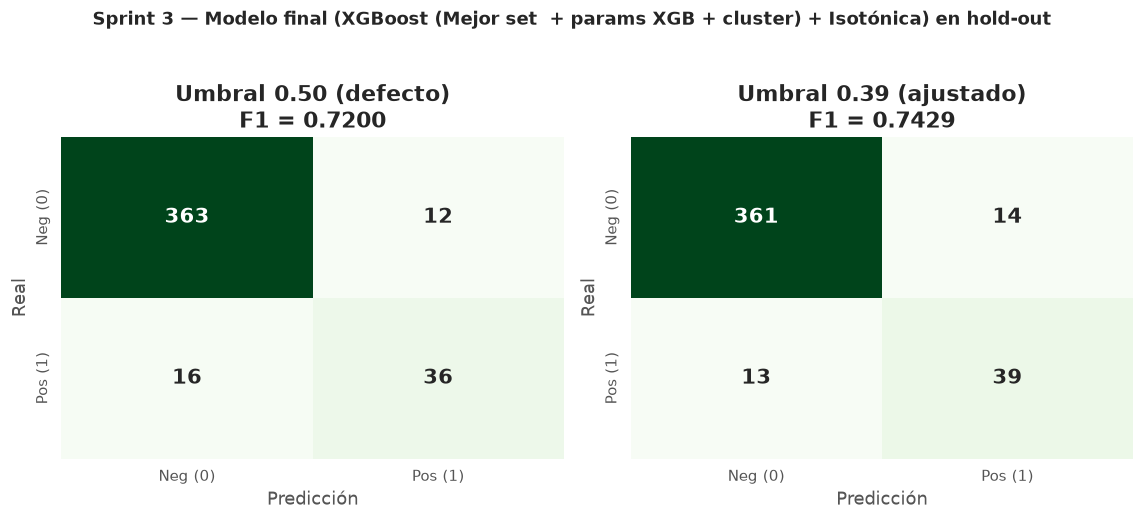

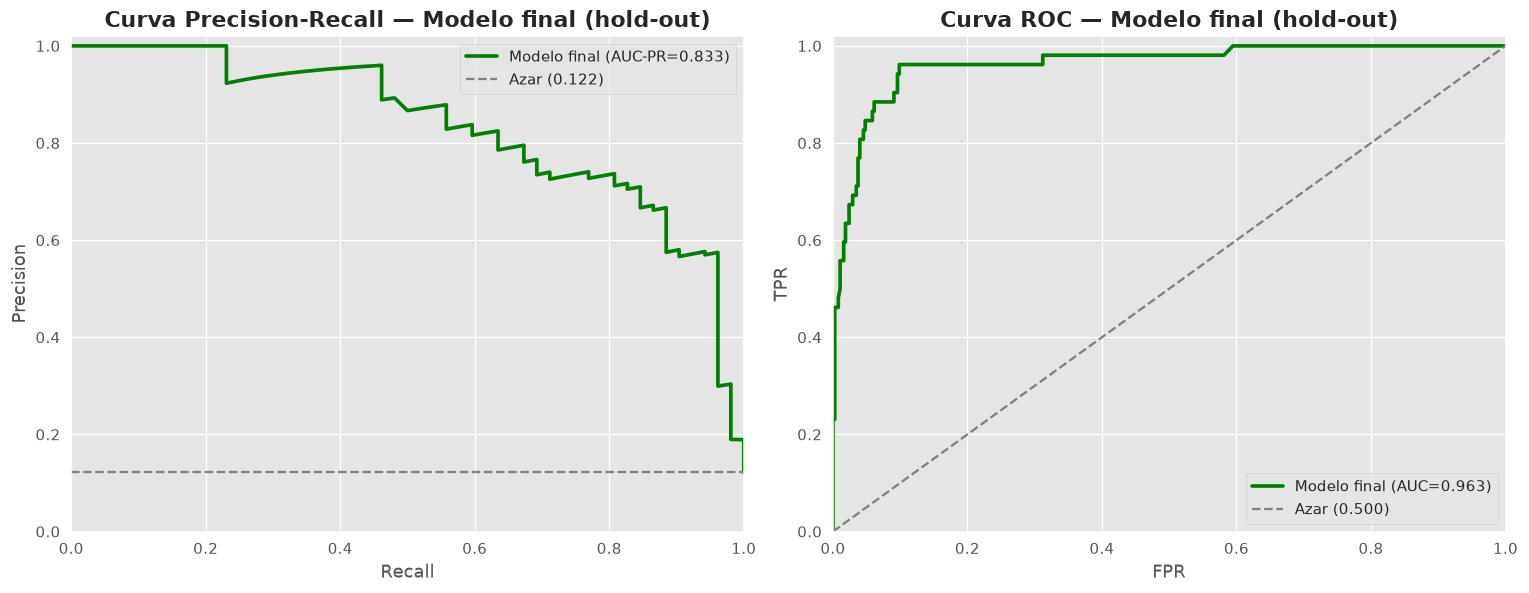

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(10.5, 4.5))
for ax, (pred, tit) in zip(axes, [( (prob_final >= 0.5).astype(int), 'Umbral 0.50 (defecto)'),
                                  (pred_final, f'Umbral {UMBRAL_OPT:.2f} (ajustado)')]):
    cm = confusion_matrix(y_test, pred)
    sns.heatmap(cm, annot=True, fmt='d', cbar=False, ax=ax, cmap='Greens',
                xticklabels=['Neg (0)', 'Pos (1)'], yticklabels=['Neg (0)', 'Pos (1)'],
                annot_kws={'size': 14, 'fontweight': 'bold'})
    ax.set_title(f'{tit}\nF1 = {f1_score(y_test, pred):.4f}', fontweight='bold')
    ax.set_xlabel('Predicción'); ax.set_ylabel('Real')
plt.suptitle(f'Sprint 3 — Modelo final ({GANADOR_NOMBRE} + {MEJOR_CAL}) en hold-out',
             fontweight='bold', y=1.04)
plt.tight_layout(); plt.savefig('outputs_sprint3/final_matrices_confusion.png', bbox_inches='tight'); plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
p, r, _ = precision_recall_curve(y_test, prob_final)
axes[0].plot(r, p, color='green', lw=2.4, label=f'Modelo final (AUC-PR={auc(r, p):.3f})')
axes[0].hlines(y_test.mean(), 0, 1, colors='gray', linestyles='--', label=f'Azar ({y_test.mean():.3f})')
axes[0].set_xlabel('Recall'); axes[0].set_ylabel('Precision'); axes[0].set_xlim(0, 1); axes[0].set_ylim(0, 1.02)
axes[0].set_title('Curva Precision-Recall — Modelo final (hold-out)', fontweight='bold'); axes[0].legend()
fpr, tpr, _ = roc_curve(y_test, prob_final)
axes[1].plot(fpr, tpr, color='green', lw=2.4, label=f'Modelo final (AUC={RES_FINAL["AUC-ROC"]:.3f})')
axes[1].plot([0, 1], [0, 1], '--', color='gray', label='Azar (0.500)')
axes[1].set_xlabel('FPR'); axes[1].set_ylabel('TPR'); axes[1].set_xlim(0, 1); axes[1].set_ylim(0, 1.02)
axes[1].set_title('Curva ROC — Modelo final (hold-out)', fontweight='bold'); axes[1].legend(loc='lower right')
plt.tight_layout(); plt.savefig('outputs_sprint3/final_curvas_pr_roc.png', bbox_inches='tight'); plt.show()

## Resumen

In [22]:
tabla_cierre = pd.DataFrame({
    'Hito': ['Sprint 1 (RF + SMOTE)', 'Sprint 2 (ganador)', 'Sprint 3 — mejor XGBoost',
             'Sprint 3 — MLP', f'Sprint 3 — FINAL (+{MEJOR_CAL}, umbral {UMBRAL_OPT:.2f})'],
    'F1 (hold-out)': [RESUMEN_S2['f1_sprint1'], RES_S2['F1'], RES_XGB_BEST['F1'],
                      RES_MLP['F1'], RES_FINAL['F1']]}).round(4)
tabla_cierre['Δ vs Sprint 2'] = (tabla_cierre['F1 (hold-out)'] - RES_S2['F1']).round(4)
tabla_cierre.to_csv('outputs_sprint3/final_cierre_sprint3.csv', index=False)
display(tabla_cierre)

resumen3 = {'ganador': GANADOR_NOMBRE, 'mejor_set_features': MEJOR_SET_NOMBRE,
            'n_features': int(XTR_FINAL.shape[1]), 'calibracion': MEJOR_CAL,
            'umbral': UMBRAL_OPT, 'f1_final': round(RES_FINAL['F1'], 4),
            'f1_sprint2': RES_S2['F1'], 'metricas_finales': {m: round(RES_FINAL[m], 4) for m in METRICAS}}
with open('outputs_sprint3/final_resumen_sprint3.json', 'w') as f:
    json.dump(resumen3, f, indent=2)

print('════════════ RESUMEN SPRINT 3 ════════════')
print(f'Mejor set de features: {MEJOR_SET_NOMBRE} ({XTR_FINAL.shape[1]} features)')
print(f'Mejor XGBoost: {MEJOR_XGB_NOMBRE} → F1 hold-out = {RES_XGB_BEST["F1"]:.4f}')
print(f'MLP (competencia justa): F1 hold-out = {RES_MLP["F1"]:.4f} → '
      f'{"superó" if RES_MLP["F1"] > RES_XGB_BEST["F1"] else "no superó"} a XGBoost')
print(f'MODELO FINAL: {GANADOR_NOMBRE} + {MEJOR_CAL} + umbral {UMBRAL_OPT:.2f}')
print(f'  F1 final = {RES_FINAL["F1"]:.4f} (Sprint 2 = {RES_S2["F1"]:.4f}, '
      f'Δ = {RES_FINAL["F1"] - RES_S2["F1"]:+.4f})')
print(f'\nEvolución del proyecto: Sprint 1 = {RESUMEN_S2["f1_sprint1"]:.4f} → '
      f'Sprint 2 = {RES_S2["F1"]:.4f} → Sprint 3 = {RES_FINAL["F1"]:.4f}')

,Hito,F1 (hold-out),Δ vs Sprint 2
0,Sprint 1 (RF + SMOTE),0.7130,-0.0906
1,Sprint 2 (ganador),0.8036,0.0000
2,Sprint 3 — mejor XGBoost,0.7664,-0.0372
3,Sprint 3 — MLP,0.6549,-0.1487
4,"Sprint 3 — FINAL (+Isotónica, umbral 0.39)",0.7429,-0.0607


════════════ RESUMEN SPRINT 3 ════════════
Mejor set de features: Top-26 + cluster XGB (31 features)
Mejor XGBoost: Mejor set  + params XGB + cluster → F1 hold-out = 0.7664
MLP (competencia justa): F1 hold-out = 0.6549 → no superó a XGBoost
MODELO FINAL: XGBoost (Mejor set  + params XGB + cluster) + Isotónica + umbral 0.39
  F1 final = 0.7429 (Sprint 2 = 0.8036, Δ = -0.0607)

Evolución del proyecto: Sprint 1 = 0.7130 → Sprint 2 = 0.8036 → Sprint 3 = 0.7429
